In [1]:
# ============================================================
# FLIGHT PRICE PREDICTION - PHASE 1
# EDA + DATA PREPROCESSING + FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("flightprice.csv", sep="\t")

# Remove unnecessary index column
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

print("=" * 60)
print("FLIGHT PRICE PREDICTION - PHASE 1")
print("=" * 60)

print("\n1. FIRST 5 ROWS")
display(df.head())

# ------------------------------------------------------------
# 2. DATASET OVERVIEW
# ------------------------------------------------------------

print("\n2. DATASET SHAPE")
print(df.shape)

print("\n3. DATASET INFORMATION")
df.info()

print("\n4. COLUMN NAMES")
print(df.columns.tolist())

FLIGHT PRICE PREDICTION - PHASE 1

1. FIRST 5 ROWS


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955



2. DATASET SHAPE
(300153, 11)

3. DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB

4. COLUMN NAMES
['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [2]:
# ------------------------------------------------------------
# 5. SUMMARY STATISTICS
# ------------------------------------------------------------

print("\n5. SUMMARY STATISTICS")
display(df.describe())



5. SUMMARY STATISTICS


,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [3]:
# ------------------------------------------------------------
# 6. MISSING VALUE ANALYSIS
# ------------------------------------------------------------

print("\n6. MISSING VALUES")
missing = df.isnull().sum()
display(missing[missing > 0])

if missing.sum() == 0:
    print("No missing values found.")



6. MISSING VALUES


Series([], dtype: int64)

No missing values found.


In [4]:
# ------------------------------------------------------------
# 7. DUPLICATE ANALYSIS
# ------------------------------------------------------------

print("\n7. DUPLICATE RECORDS")
print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after duplicate removal:", df.shape)


7. DUPLICATE RECORDS


Duplicate rows: 0
Shape after duplicate removal: (300153, 11)


In [5]:
# ----------------------------------------
# 8. DATA TYPES
# ----------------------------------------

print("\n8. DATA TYPES")
display(df.dtypes)

# ----------------------------------------
# 9. NUMERIC AND CATEGORICAL COLUMNS
# ----------------------------------------

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("\n9. NUMERIC COLUMNS")
print(numeric_cols)

print("\n10. CATEGORICAL COLUMNS")
print(categorical_cols)



8. DATA TYPES


airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object


9. NUMERIC COLUMNS
['duration', 'days_left', 'price']

10. CATEGORICAL COLUMNS
['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']


In [6]:
# ------------------------------------------------------------
# 11. OUTLIER ANALYSIS
# ------------------------------------------------------------

print("\n11. OUTLIER ANALYSIS")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers, "outliers")



11. OUTLIER ANALYSIS


duration : 2110 outliers
days_left : 0 outliers
price : 123 outliers


In [7]:
# ------------------------------------------------------------
# 12. SKEWNESS ANALYSIS
# ------------------------------------------------------------

print("\n12. SKEWNESS")
display(df[numeric_cols].skew().sort_values(ascending=False))



12. SKEWNESS


price        1.061377
duration     0.602899
days_left   -0.035464
dtype: float64

In [8]:
# ------------------------------------------------------------
# 13. CORRELATION ANALYSIS
# ------------------------------------------------------------

print("\n13. CORRELATION WITH PRICE")

if "price" in df.columns:
    correlation = df[numeric_cols].corr()["price"].sort_values(ascending=False)
    display(correlation)



13. CORRELATION WITH PRICE


price        1.000000
duration     0.204222
days_left   -0.091949
Name: price, dtype: float64

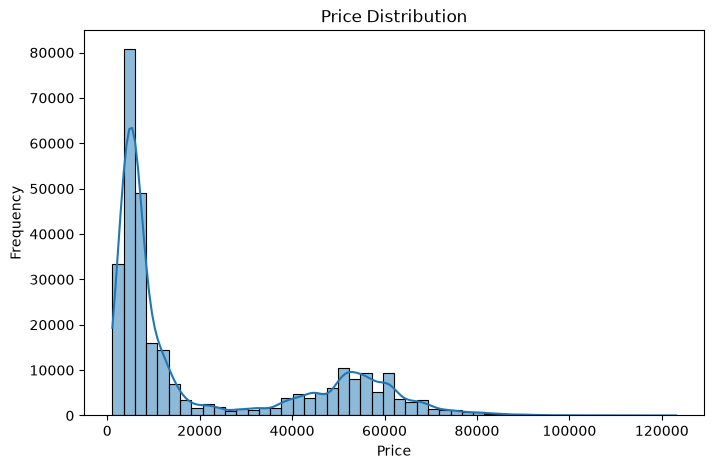

In [9]:
# ------------------------------------------------------------
# 14. VISUALIZATION 1 - PRICE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


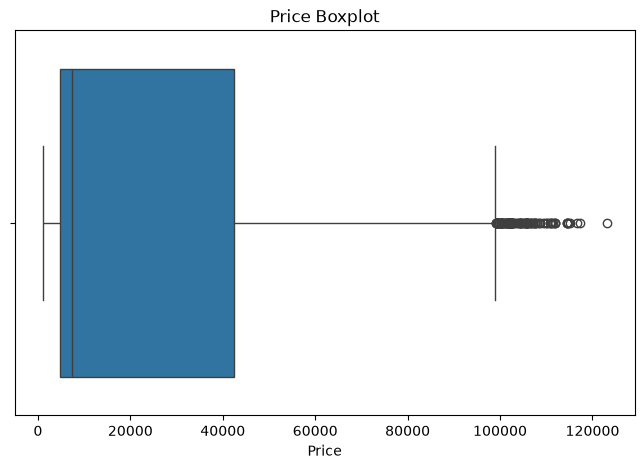

In [10]:
# ------------------------------------------------------------
# 15. VISUALIZATION 2 - PRICE BOXPLOT
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Price Boxplot")
plt.xlabel("Price")
plt.show()


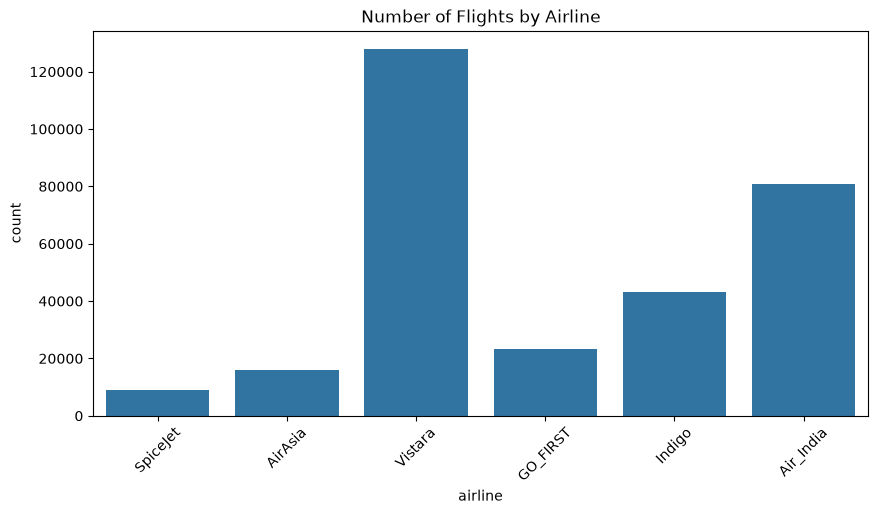

In [11]:
# ------------------------------------------------------------
# 16. VISUALIZATION 3 - AIRLINE COUNT
# ------------------------------------------------------------

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="airline")
plt.title("Number of Flights by Airline")
plt.xticks(rotation=45)
plt.show()

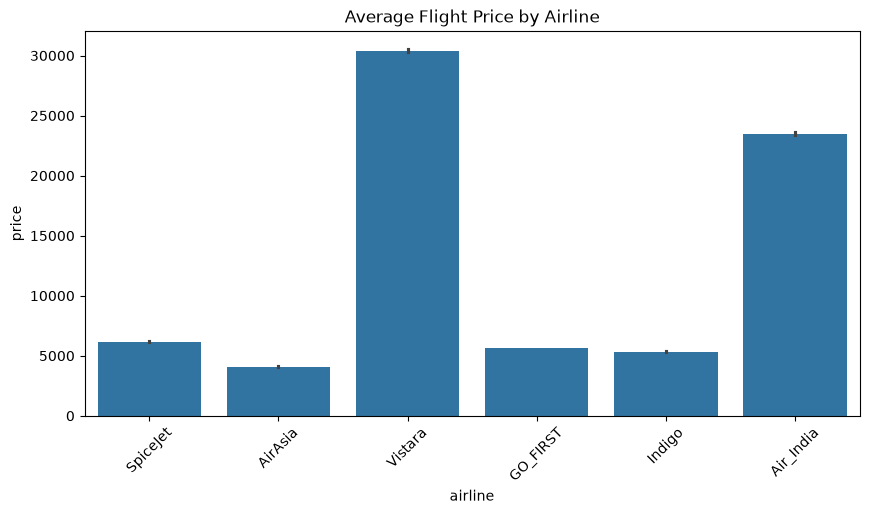

In [12]:
# ------------------------------------------------------------
# 17. VISUALIZATION 4 - AVERAGE PRICE BY AIRLINE
# ------------------------------------------------------------

plt.figure(figsize=(10,5))
sns.barplot(data=df, x="airline", y="price", estimator="mean")
plt.title("Average Flight Price by Airline")
plt.xticks(rotation=45)
plt.show()


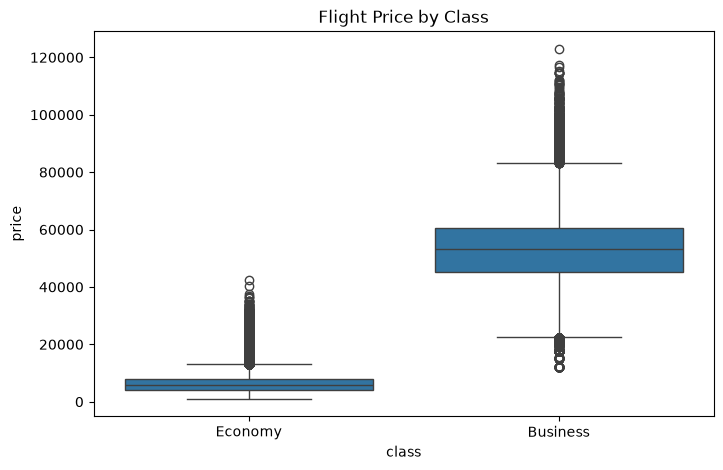

In [13]:
# ------------------------------------------------------------
# 18. VISUALIZATION 5 - PRICE BY CLASS
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="class", y="price")
plt.title("Flight Price by Class")
plt.show()


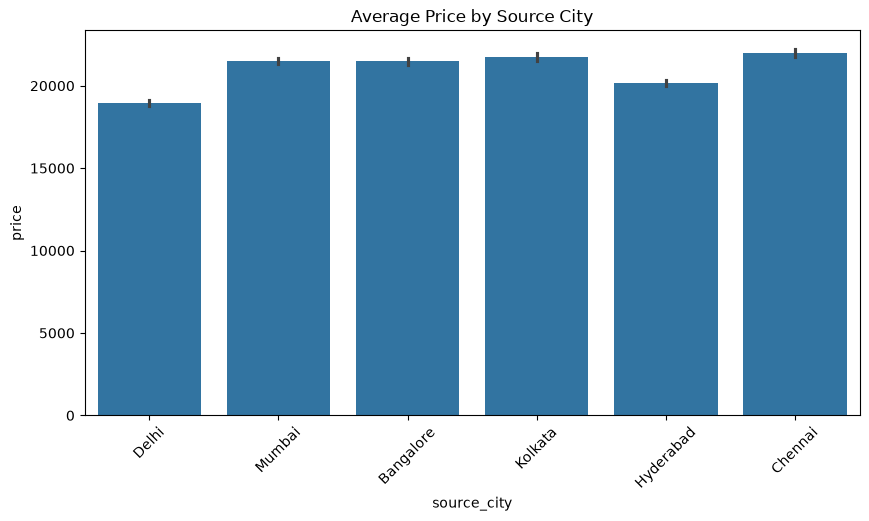

In [14]:
# ------------------------------------------------------------
# 19. VISUALIZATION 6 - PRICE BY SOURCE CITY
# ------------------------------------------------------------

plt.figure(figsize=(10,5))
sns.barplot(data=df, x="source_city", y="price", estimator="mean")
plt.title("Average Price by Source City")
plt.xticks(rotation=45)
plt.show()


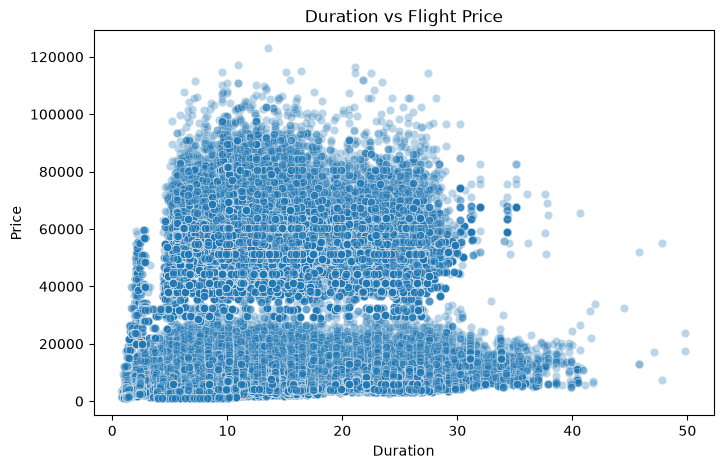

In [15]:
# ------------------------------------------------------------
# 20. VISUALIZATION 7 - DURATION VS PRICE
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="duration", y="price", alpha=0.3)
plt.title("Duration vs Flight Price")
plt.xlabel("Duration")
plt.ylabel("Price")
plt.show()

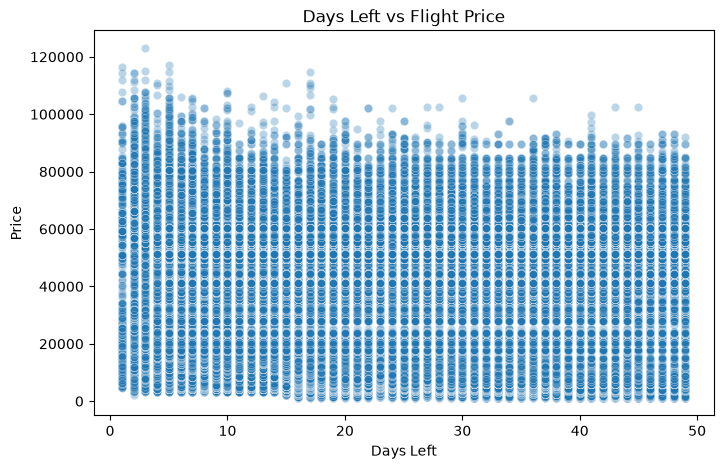

In [16]:
# ------------------------------------------------------------
# 21. VISUALIZATION 8 - DAYS LEFT VS PRICE
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="days_left", y="price", alpha=0.3)
plt.title("Days Left vs Flight Price")
plt.xlabel("Days Left")
plt.ylabel("Price")
plt.show()

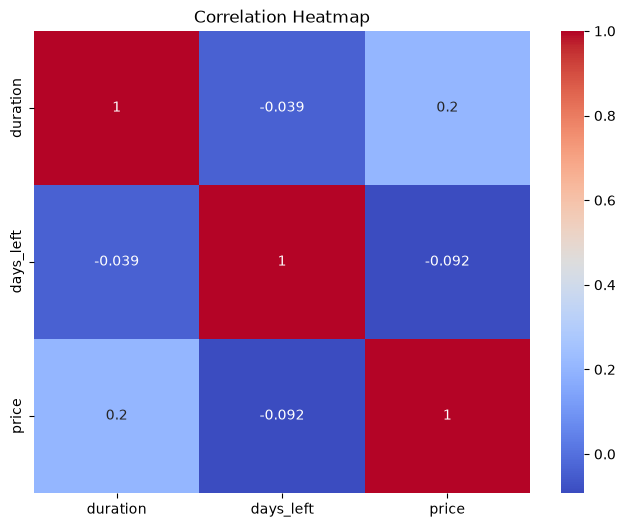

In [17]:
# ------------------------------------------------------------
# 22. VISUALIZATION 9 - CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [18]:
# ------------------------------------------------------------
# 23. DATA PREPROCESSING
# ------------------------------------------------------------

print("\n23. DATA PREPROCESSING")

# Fill missing numeric values
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled.")



23. DATA PREPROCESSING
Missing values handled.


In [19]:
# ------------------------------------------------------------
# 24. OUTLIER TREATMENT
# ------------------------------------------------------------

# Treat outliers in numeric INPUT features only
feature_numeric = [c for c in numeric_cols if c != "price"]

for col in feature_numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers treated using IQR capping.")


Outliers treated using IQR capping.


In [20]:
# ------------------------------------------------------------
# 25. SKEWNESS TREATMENT
# ------------------------------------------------------------

# Log transformation for positively skewed numeric features
for col in feature_numeric:
    if df[col].skew() > 1:
        df[col] = np.log1p(df[col])

print("Skewness treatment completed.")


Skewness treatment completed.


In [21]:
# ------------------------------------------------------------
# 26. DROP HIGH-CARDINALITY FLIGHT COLUMN
# ------------------------------------------------------------

if "flight" in df.columns:
    df = df.drop("flight", axis=1)

print("\nFlight identifier column removed.")



Flight identifier column removed.


In [22]:
# 27. FEATURE ENGINEERING - ONE HOT ENCODING

X = df.drop("price", axis=1)
y = df["price"]

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

# One-Hot Encoding
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("\n27. ENCODED DATA SHAPE")
print(X_encoded.shape)


27. ENCODED DATA SHAPE
(300153, 30)


In [23]:
 #------------------------------------------------------------
# 28. TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("\n28. TRAIN TEST SPLIT")
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


28. TRAIN TEST SPLIT
Training data: (240122, 30)
Testing data : (60031, 30)


In [24]:
# ------------------------------------------------------------
# 29. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n29. FEATURE SCALING COMPLETED")



29. FEATURE SCALING COMPLETED


In [25]:
# ------------------------------------------------------------
# 30. CORRELATION-BASED FEATURE SELECTION
# ------------------------------------------------------------

train_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

train_df["price"] = y_train

corr = train_df.corr()["price"].drop("price").abs().sort_values(
    ascending=False
)

print("\n30. TOP FEATURES USING CORRELATION")
display(corr.head(10))

# Select top 10 correlation features
top_corr_features = corr.head(10).index.tolist()

X_train_corr = train_df[top_corr_features].copy()

X_test_corr = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)[top_corr_features]

print("Selected correlation features:")
print(top_corr_features)



30. TOP FEATURES USING CORRELATION


class_Economy              0.937802
airline_Vistara            0.359918
airline_Indigo             0.280668
duration                   0.205663
airline_GO_FIRST           0.194279
stops_zero                 0.187163
airline_SpiceJet           0.114263
arrival_time_Late_Night    0.093265
days_left                  0.092163
airline_Air_India          0.070846
Name: price, dtype: float64

Selected correlation features:
['class_Economy', 'airline_Vistara', 'airline_Indigo', 'duration', 'airline_GO_FIRST', 'stops_zero', 'airline_SpiceJet', 'arrival_time_Late_Night', 'days_left', 'airline_Air_India']


In [26]:
# ------------------------------------------------------------
# 31. SELECTKBEST
# ------------------------------------------------------------

k = min(10, X_train_scaled.shape[1])

selector = SelectKBest(score_func=f_regression, k=k)

X_train_kbest = selector.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector.transform(X_test_scaled)

selected_features = X_train.columns[selector.get_support()]

print("\n31. SELECTKBEST FEATURES")
print(selected_features.tolist())

print("\nSelectKBest Training Shape:", X_train_kbest.shape)
print("SelectKBest Testing Shape :", X_test_kbest.shape)



31. SELECTKBEST FEATURES
['duration', 'days_left', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'stops_zero', 'arrival_time_Late_Night', 'class_Economy']

SelectKBest Training Shape: (240122, 10)
SelectKBest Testing Shape : (60031, 10)


In [27]:
# ------------------------------------------------------------
# 32. FINAL PHASE 1 SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PHASE 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
✓ Dataset Overview
✓ Summary Statistics
✓ Missing Value Analysis
✓ Missing Value Handling
✓ Duplicate Removal
✓ Outlier Analysis & Treatment
✓ Skewness Analysis & Treatment
✓ Correlation Analysis
✓ 8+ Visualizations
✓ Categorical Encoding
✓ Feature Scaling
✓ Feature Engineering
✓ Correlation-Based Feature Selection
✓ SelectKBest Feature Selection
✓ Train/Test Split
""")


PHASE 1 COMPLETED SUCCESSFULLY

✓ Dataset Overview
✓ Summary Statistics
✓ Missing Value Analysis
✓ Missing Value Handling
✓ Duplicate Removal
✓ Outlier Analysis & Treatment
✓ Skewness Analysis & Treatment
✓ Correlation Analysis
✓ 8+ Visualizations
✓ Categorical Encoding
✓ Feature Scaling
✓ Feature Engineering
✓ Correlation-Based Feature Selection
✓ SelectKBest Feature Selection
✓ Train/Test Split



In [28]:
# ============================================================
# FLIGHT PRICE PREDICTION - COMPLETE REGRESSION PROJECT
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("flightprice.csv", sep=None, engine="python")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset Shape: (300153, 12)

Columns:
['unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [29]:
# ============================================================
# 2. FIND PRICE COLUMN
# ============================================================

# Handle Price / price / PRICE automatically
price_columns = [c for c in df.columns if c.strip().lower() == "price"]

if len(price_columns) == 0:
    raise ValueError(
        "Price column not found. Available columns are:\n"
        + str(df.columns.tolist())
    )

target = price_columns[0]

print("\nTarget Column:", target)


Target Column: price


In [30]:
# ============================================================
# 3. BASIC DATA CLEANING
# ============================================================

# Remove completely empty rows
df = df.dropna(how="all").copy()

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Convert price to numeric
df[target] = pd.to_numeric(df[target], errors="coerce")

# Remove rows where price is missing
df = df.dropna(subset=[target]).copy()



In [31]:
# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

# Convert duration such as:
# 2h 50m -> 2.8333 hours
# 5h -> 5 hours
# 50m -> 0.8333 hours

if "duration" in df.columns:

    def convert_duration(value):
        if pd.isna(value):
            return np.nan

        value = str(value).strip().lower()

        hours = 0
        minutes = 0

        if "h" in value:
            try:
                hours = float(value.split("h")[0].strip())
            except:
                hours = 0

        if "m" in value:
            try:
                minute_part = value.split("h")[-1]
                minute_part = minute_part.replace("m", "").strip()
                if minute_part:
                    minutes = float(minute_part)
            except:
                minutes = 0

        return hours + minutes / 60

    df["duration_hours"] = df["duration"].apply(convert_duration)

    # Remove original text duration
    df = df.drop(columns=["duration"])


In [32]:
# ============================================================
# 5. REMOVE UNNECESSARY ID COLUMN
# ============================================================

if "flight" in df.columns:
    df = df.drop(columns=["flight"])

In [33]:
# ============================================================
# 6. SEPARATE X AND y
# ============================================================

X = df.drop(columns=[target])
y = df[target]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (300153, 10)
y Shape: (300153,)


In [34]:
# ============================================================
# 7. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numeric_columns = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

categorical_columns = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNumerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)


Numerical Columns:
['unnamed: 0', 'days_left', 'duration_hours']

Categorical Columns:
['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']


In [35]:
# ============================================================
# 8. HANDLE MISSING VALUES
# ============================================================

for col in numeric_columns:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])


In [36]:
# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)




Training Data: (240122, 10)
Testing Data : (60031, 10)


In [37]:
# ============================================================
# 10. ENCODING + FEATURE SCALING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_columns
        )
    ]
)


In [38]:
# ============================================================
# 11. LINEAR REGRESSION
# ============================================================

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)


In [39]:
# ============================================================
# 12. RIDGE REGRESSION
# ============================================================

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)



In [ ]:
# ============================================================
# 13. LASSO REGRESSION
# ============================================================

lasso_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.001, max_iter=5000))
    ]
)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)



In [ ]:
# ============================================================
# 14. POLYNOMIAL REGRESSION
# ============================================================
# Polynomial features are applied only to numerical variables.
# This avoids creating an extremely large matrix from categorical data.

poly_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric_poly",
            Pipeline(
                steps=[
                    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                    ("scaler", StandardScaler())
                ]
            ),
            numeric_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_columns
        )
    ]
)

poly_model = Pipeline(
    steps=[
        ("preprocessor", poly_preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)


In [ ]:
# ============================================================
# 15. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    mse = mean_squared_error(actual, predicted)

    rmse = np.sqrt(mse)

    r2 = r2_score(actual, predicted)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }



In [ ]:
# ============================================================
# 16. COMPARE ALL MODELS
# ============================================================

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Polynomial Regression",
        y_test,
        poly_pred
    )
)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_pred
    )
)

results.append(
    evaluate_model(
        "Lasso Regression",
        y_test,
        lasso_pred
    )
)

results_df = pd.DataFrame(results)


In [ ]:
# ============================================================
# 17. DISPLAY RESULTS
# ============================================================

print("\n================ MODEL COMPARISON ================\n")

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)



================ MODEL COMPARISON ================

                Model       MAE           MSE      RMSE  R2 Score
    Linear Regression 4543.0598 45432601.7087 6740.3710    0.9119
Polynomial Regression 4409.6527 43966447.9308 6630.7200    0.9147
     Ridge Regression 4542.9709 45431647.6840 6740.3003    0.9119
     Lasso Regression 4543.0589 45432600.8025 6740.3710    0.9119


In [ ]:
# ============================================================
# 18. ACTUAL VS PREDICTED VALUES
# ============================================================

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Linear Prediction": linear_pred,
    "Polynomial Prediction": poly_pred,
    "Ridge Prediction": ridge_pred,
    "Lasso Prediction": lasso_pred
})

print("\n================ SAMPLE PREDICTIONS ================\n")

print(comparison.head(10))



================ SAMPLE PREDICTIONS ================

   Actual Price  Linear Prediction  Polynomial Prediction  Ridge Prediction  \
0          7366        3770.385703            3669.778647       3760.238213   
1         64831       55672.767603           57089.803282      55670.408691   
2          6195       10158.795356           10451.887098      10158.361498   
3         60160       56092.142179           54525.222722      56089.344400   
4          6578        6846.795408            5635.045285       6846.945390   
5          4555        9417.773994           11104.293797       9421.570685   
6         23838       49374.931398           48863.496748      49374.990890   
7          3860        6176.681331            7637.251611       6175.634694   
8         32230       48567.341246           50660.319389      48569.646303   
9         76841       57235.644830           58879.760231      57242.198469   

   Lasso Prediction  
0       3770.392395  
1      55672.726609  
2      10

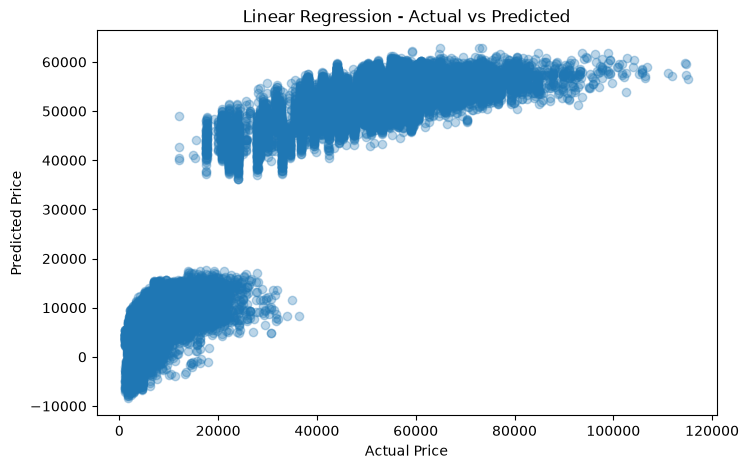

In [ ]:
# ============================================================
# 19. ACTUAL VS PREDICTED GRAPH - LINEAR REGRESSION
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    linear_pred,
    alpha=0.3
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression - Actual vs Predicted")

plt.show()


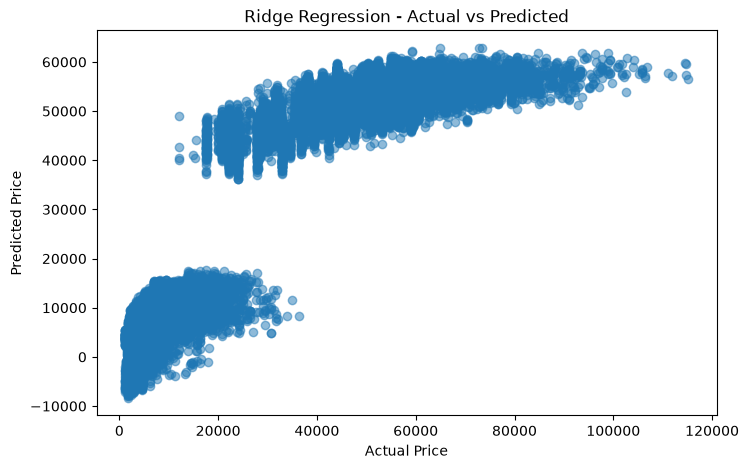

In [ ]:
# ============================================================
# 20. ACTUAL VS PREDICTED GRAPH - RIDGE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    ridge_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression - Actual vs Predicted")

plt.show()


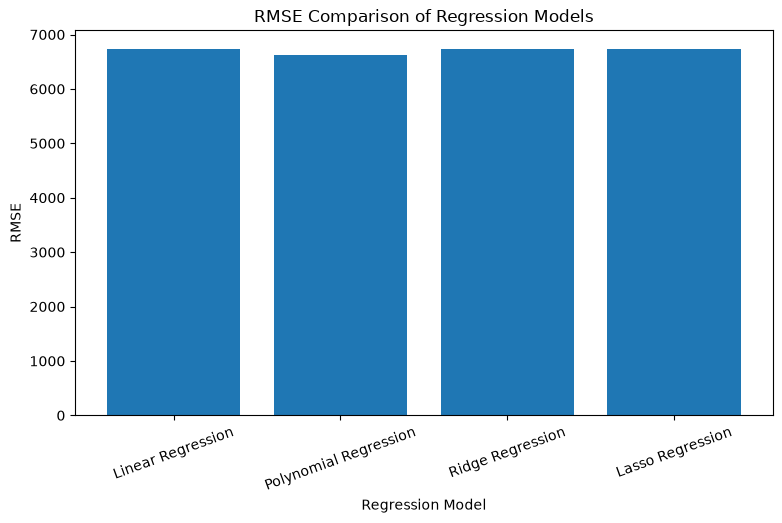

In [ ]:
# ============================================================
# 21. MODEL RMSE COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Regression Models")

plt.xticks(rotation=20)

plt.show()



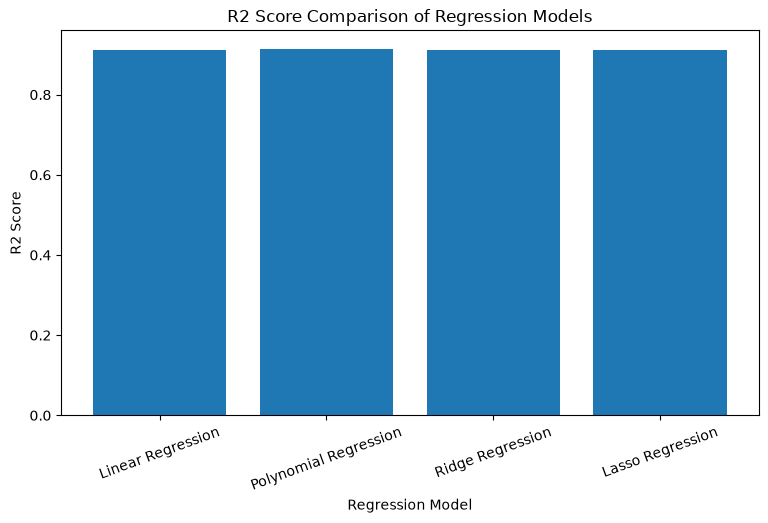

In [ ]:
# ============================================================
# 22. MODEL R2 COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.xlabel("Regression Model")
plt.ylabel("R2 Score")
plt.title("R2 Score Comparison of Regression Models")

plt.xticks(rotation=20)

plt.show()



In [ ]:
# ============================================================
# 23. PROJECT SUMMARY
# ============================================================

print("\n================ PROJECT SUMMARY ================\n")

print("Dataset:", "flightprice.csv")
print("Target:", target)

print("\nModels Built:")
print("1. Linear Regression")
print("2. Polynomial Regression")
print("3. Ridge Regression")
print("4. Lasso Regression")

print("\nEvaluation Metrics:")
print("1. MAE - Mean Absolute Error")
print("2. MSE - Mean Squared Error")
print("3. RMSE - Root Mean Squared Error")
print("4. R2 Score - Coefficient of Determination")

print("\nProject completed successfully.")



================ PROJECT SUMMARY ================

Dataset: flightprice.csv
Target: price

Models Built:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression

Evaluation Metrics:
1. MAE - Mean Absolute Error
2. MSE - Mean Squared Error
3. RMSE - Root Mean Squared Error
4. R2 Score - Coefficient of Determination

Project completed successfully.
